# FE za dataset *Otkrivanje transakcijskih prijevara*
 https://www.kaggle.com/competitions/dap-fer2025

In [135]:
import pandas as pd
import matplotlib.pyplot as plt

## 0. Čišćenje dataseta (ponavljanje iz EDA bilježnice)

In [140]:
df = pd.read_csv('dataset.csv')

# brisanje značajke Is_Contactless
del df['Is_Contactless']

# uklanjanje zapisa gdje nedostaju podaci, svi od USER_0007
df = df[df['User_ID'] != 'USER_0007']

# korekcija neujednačenog označavanja
df['Location'] = df['Location'].replace('Lndn', 'London')
df['Merchant_Category'] = df['Merchant_Category'].replace('Electronis', 'Electronics')


# izbacivanje negativnih i transakcija s iznosom 0
df = df.loc[df['Transaction_Amount'] > 0, :]

# popravljanje Is_Weekend
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df['Is_Weekend'] = df["Timestamp"].dt.dayofweek >= 5

df


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0.0,...,7.0,437.63,3.0,Amex,65.0,883.17,Biometric,0.8494,False,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0.0,...,13.0,478.76,4.0,Mastercard,186.0,2203.36,Password,0.0959,False,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0.0,...,14.0,50.01,4.0,Visa,226.0,1909.29,Biometric,0.8400,False,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0.0,...,8.0,182.48,4.0,Visa,76.0,1311.86,OTP,0.7935,False,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0.0,...,14.0,328.69,4.0,Mastercard,140.0,966.98,Password,0.3819,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50007,TXN_11284,USER_4796,45.05,Online,2023-01-29 18:38:00,76960.11,Mobile,Tokyo,Clothing,0.0,...,2.0,389.00,3.0,Amex,98.0,1537.54,PIN,0.1493,True,0
50008,TXN_44732,USER_1171,126.15,POS,2023-05-09 08:55:00,28791.75,Mobile,Tokyo,Clothing,0.0,...,13.0,434.95,4.0,Visa,93.0,2555.72,Biometric,0.3653,False,1
50009,TXN_38158,USER_2510,72.02,Online,2023-01-30 19:32:00,29916.41,Laptop,Mumbai,Clothing,0.0,...,1.0,369.15,2.0,Visa,114.0,4686.59,Biometric,0.5195,False,0
50010,TXN_860,USER_2248,64.89,Bank Transfer,2023-03-09 19:47:00,67895.67,Mobile,Tokyo,Electronics,0.0,...,13.0,242.29,4.0,Discover,72.0,4886.92,Biometric,0.7063,False,1


# 1. Transformacije varijabli

**A) Pretvorba kategoričkih u numeričke - one-hot encoding**

In [141]:
df = pd.get_dummies(df, columns=['Transaction_Type'], prefix='TT')
df = pd.get_dummies(df, columns=['Device_Type'], prefix='DT')
df = pd.get_dummies(df, columns=['Location'], prefix='Loc')
df = pd.get_dummies(df, columns=['Merchant_Category'], prefix='MerchCat')
df = pd.get_dummies(df, columns=['Card_Type'], prefix='CT')
df = pd.get_dummies(df, columns=['Authentication_Method'], prefix='AUM')

**B) Normalizacija**

In [142]:
# MIN-MAX
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_cols = ['Transaction_Amount', 'Account_Balance']

df_minmax = df.copy()
df_minmax[num_cols] = scaler.fit_transform(df[num_cols])

In [143]:
# Z-SCORE

from sklearn.preprocessing import StandardScaler

zscaler = StandardScaler()

df_zscore = df.copy()
df_zscore[num_cols] = zscaler.fit_transform(df[num_cols])

Text(0, 0.5, 'Balance')

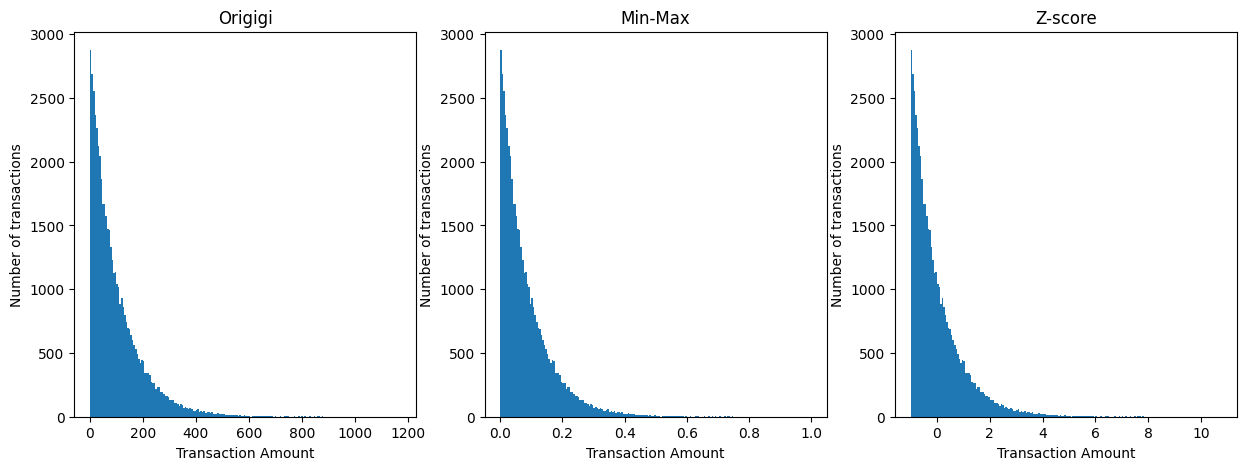

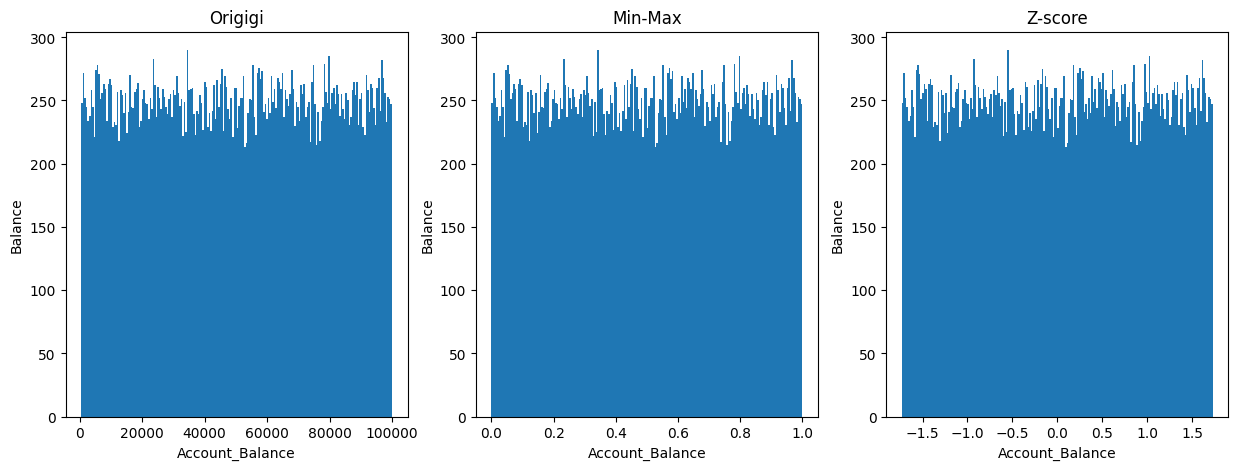

In [144]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(df['Transaction_Amount'], bins=200)
ax[0].set_title('Origigi')
ax[0].set_xlabel('Transaction Amount')
ax[0].set_ylabel('Number of transactions')

ax[1].hist(df_minmax['Transaction_Amount'], bins=200)
ax[1].set_title('Min-Max')
ax[1].set_xlabel('Transaction Amount')
ax[1].set_ylabel('Number of transactions')

ax[2].hist(df_zscore['Transaction_Amount'], bins=200)
ax[2].set_title('Z-score')
ax[2].set_xlabel('Transaction Amount')
ax[2].set_ylabel('Number of transactions')



fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(df['Account_Balance'], bins=200)
ax[0].set_title('Origigi')
ax[0].set_xlabel('Account_Balance')
ax[0].set_ylabel('Balance')

ax[1].hist(df_minmax['Account_Balance'], bins=200)
ax[1].set_title('Min-Max')
ax[1].set_xlabel('Account_Balance')
ax[1].set_ylabel('Balance')

ax[2].hist(df_zscore['Account_Balance'], bins=200)
ax[2].set_title('Z-score')
ax[2].set_xlabel('Account_Balance')
ax[2].set_ylabel('Balance')

**C. Log-transform**
-log1p(x) računa log(1 + x), čime se izbjegava problem s log(0) = -∞

In [146]:
import numpy as np

df_log = df.copy()
df_log['Transaction_Amount'] = np.log1p(df['Transaction_Amount'])
df_log['Account_Balance'] = np.log1p(df['Account_Balance'])

In [119]:
df_log

,Transaction_ID,User_ID,Transaction_Amount,Timestamp,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,...,MerchCat_Restaurants,MerchCat_Travel,CT_Amex,CT_Discover,CT_Mastercard,CT_Visa,AUM_Biometric,AUM_OTP,AUM_PIN,AUM_Password
0,TXN_33553,USER_1834,3.708437,2023-08-14 19:30:00,11.442655,0.0,0.0,7.0,437.63,3.0,...,False,True,True,False,False,False,True,False,False,False
1,TXN_9427,USER_7875,0.783902,2023-06-07 04:01:00,11.234880,0.0,0.0,13.0,478.76,4.0,...,False,False,False,False,True,False,False,False,False,True
2,TXN_199,USER_2734,3.399863,2023-06-20 15:25:00,7.371464,0.0,0.0,14.0,50.01,4.0,...,True,False,False,False,False,True,True,False,False,False
3,TXN_12447,USER_2617,5.542518,2023-12-07 00:31:00,11.249067,0.0,0.0,8.0,182.48,4.0,...,False,False,False,False,False,True,False,True,False,False
4,TXN_39489,USER_2014,3.474448,2023-11-11 23:44:00,11.433402,0.0,1.0,14.0,328.69,4.0,...,False,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50007,TXN_11284,USER_4796,3.829728,2023-01-29 18:38:00,11.251056,0.0,0.0,2.0,389.00,3.0,...,False,False,True,False,False,False,False,False,True,False
50008,TXN_44732,USER_1171,4.845367,2023-05-09 08:55:00,10.267879,0.0,0.0,13.0,434.95,4.0,...,False,False,False,False,False,True,True,False,False,False
50009,TXN_38158,USER_2510,4.290733,2023-01-30 19:32:00,10.306196,0.0,1.0,1.0,369.15,2.0,...,False,False,False,False,False,True,True,False,False,False
50010,TXN_860,USER_2248,4.187987,2023-03-09 19:47:00,11.125742,0.0,0.0,13.0,242.29,4.0,...,False,False,False,True,False,False,True,False,False,False


Text(0, 0.5, 'Balance')

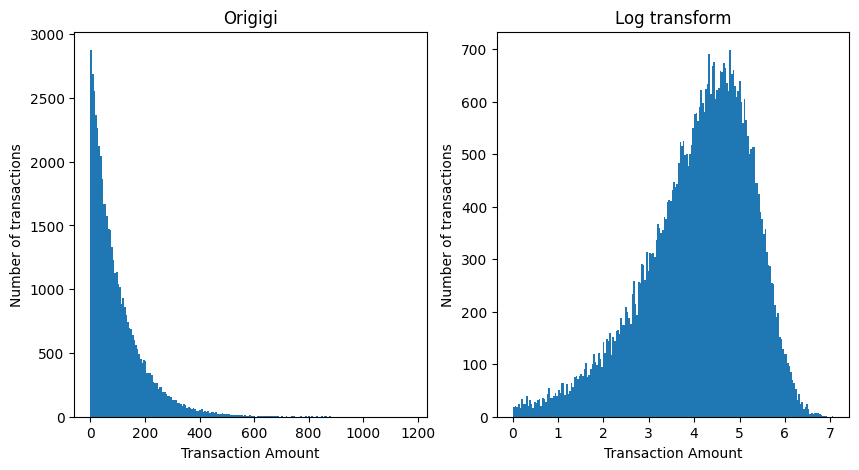

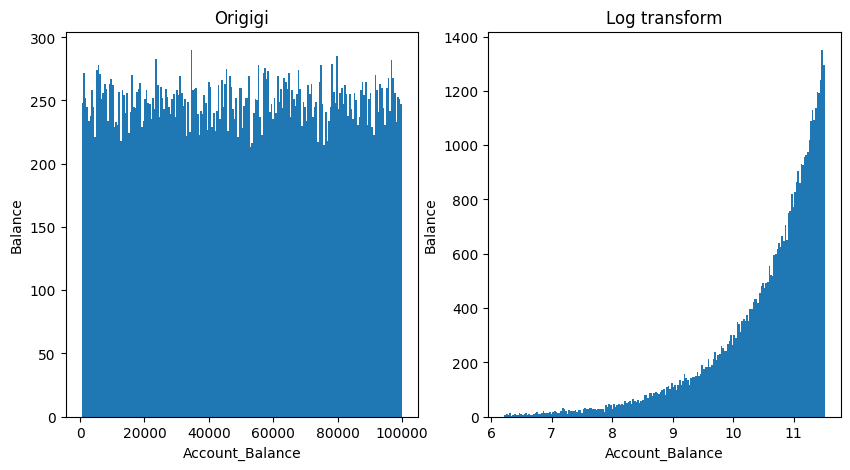

In [147]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(df['Transaction_Amount'], bins=200)
ax[0].set_title('Origigi')
ax[0].set_xlabel('Transaction Amount')
ax[0].set_ylabel('Number of transactions')

ax[1].hist(df_log['Transaction_Amount'], bins=200)
ax[1].set_title('Log transform')
ax[1].set_xlabel('Transaction Amount')
ax[1].set_ylabel('Number of transactions')


fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(df['Account_Balance'], bins=200)
ax[0].set_title('Origigi')
ax[0].set_xlabel('Account_Balance')
ax[0].set_ylabel('Balance')

ax[1].hist(df_log['Account_Balance'], bins=200)
ax[1].set_title('Log transform')
ax[1].set_xlabel('Account_Balance')
ax[1].set_ylabel('Balance')



**D. Transfomacija datuma**

In [148]:
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month
df["Year"] = df["Timestamp"].dt.year
df["Day_of_Week"] = df["Timestamp"].dt.dayofweek
df["Quarter"] = df["Timestamp"].dt.quarter


#cyclic
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["DOW_sin"] = np.sin(2 * np.pi * df["Day_of_Week"] / 7)
df["DOW_cos"] = np.cos(2 * np.pi * df["Day_of_Week"] / 7)
df["Day_sin"] = np.sin(2 * np.pi * df["Day"] / 31)
df["Day_cos"] = np.cos(2 * np.pi * df["Day"] / 31)

In [122]:
df

,Transaction_ID,User_ID,Transaction_Amount,Timestamp,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,...,Month,Year,Day_of_Week,Quarter,Month_sin,Month_cos,DOW_sin,DOW_cos,Day_sin,Day_cos
0,TXN_33553,USER_1834,39.79,2023-08-14 19:30:00,93213.17,0.0,0.0,7.0,437.63,3.0,...,8,2023,0,3,-8.660254e-01,-5.000000e-01,0.000000,1.000000,0.299363,-0.954139
1,TXN_9427,USER_7875,1.19,2023-06-07 04:01:00,75725.25,0.0,0.0,13.0,478.76,4.0,...,6,2023,2,2,1.224647e-16,-1.000000e+00,0.974928,-0.222521,0.988468,0.151428
2,TXN_199,USER_2734,28.96,2023-06-20 15:25:00,1588.96,0.0,0.0,14.0,50.01,4.0,...,6,2023,1,2,1.224647e-16,-1.000000e+00,0.781831,0.623490,-0.790776,-0.612106
3,TXN_12447,USER_2617,254.32,2023-12-07 00:31:00,76807.20,0.0,0.0,8.0,182.48,4.0,...,12,2023,3,4,-2.449294e-16,1.000000e+00,0.433884,-0.900969,0.988468,0.151428
4,TXN_39489,USER_2014,31.28,2023-11-11 23:44:00,92354.66,0.0,1.0,14.0,328.69,4.0,...,11,2023,5,4,-5.000000e-01,8.660254e-01,-0.974928,-0.222521,0.790776,-0.612106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50007,TXN_11284,USER_4796,45.05,2023-01-29 18:38:00,76960.11,0.0,0.0,2.0,389.00,3.0,...,1,2023,6,1,5.000000e-01,8.660254e-01,-0.781831,0.623490,-0.394356,0.918958
50008,TXN_44732,USER_1171,126.15,2023-05-09 08:55:00,28791.75,0.0,0.0,13.0,434.95,4.0,...,5,2023,1,2,5.000000e-01,-8.660254e-01,0.781831,0.623490,0.968077,-0.250653
50009,TXN_38158,USER_2510,72.02,2023-01-30 19:32:00,29916.41,0.0,1.0,1.0,369.15,2.0,...,1,2023,0,1,5.000000e-01,8.660254e-01,0.000000,1.000000,-0.201299,0.979530
50010,TXN_860,USER_2248,64.89,2023-03-09 19:47:00,67895.67,0.0,0.0,13.0,242.29,4.0,...,3,2023,3,1,1.000000e+00,6.123234e-17,0.433884,-0.900969,0.968077,-0.250653


**E. Konačni odabir transfomacija numeričkih varijabli**
- log transform za 'Transaction_Amount'
- z-score za numeričke (osim sin/cos i onih dobivenih iz kategoričkih)

In [149]:
df_transformed = df.copy()
df_transformed['Transaction_Amount'] = df_log['Transaction_Amount']

from sklearn.preprocessing import StandardScaler

zscaler2 = StandardScaler()
scale_cols = ['Account_Balance', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance']
df_transformed[scale_cols] = zscaler2.fit_transform(df[scale_cols])
del df_transformed['Timestamp']
del df_transformed['Day_of_Week']
del df_transformed['Day']
del df_transformed['Month']
del df_transformed['Year']
del df_transformed['Quarter']


In [150]:
df_transformed

,Transaction_ID,User_ID,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,...,AUM_Biometric,AUM_OTP,AUM_PIN,AUM_Password,Month_sin,Month_cos,DOW_sin,DOW_cos,Day_sin,Day_cos
0,TXN_33553,USER_1834,3.708437,1.492379,0.0,0.0,-0.120064,1.289857,0.704553,-0.797232,...,True,False,False,False,-8.660254e-01,-5.000000e-01,0.000000,1.000000,0.299363,-0.954139
1,TXN_9427,USER_7875,0.783902,0.884311,0.0,0.0,1.365269,1.580771,1.411637,0.956808,...,False,False,False,True,1.224647e-16,-1.000000e+00,0.974928,-0.222521,0.988468,0.151428
2,TXN_199,USER_2734,3.399863,-1.693463,0.0,0.0,1.612825,-1.451796,1.411637,1.536656,...,True,False,False,False,1.224647e-16,-1.000000e+00,0.781831,0.623490,-0.790776,-0.612106
3,TXN_12447,USER_2617,5.542518,0.921932,0.0,0.0,0.127491,-0.514830,1.411637,-0.637774,...,False,True,False,False,-2.449294e-16,1.000000e+00,0.433884,-0.900969,0.988468,0.151428
4,TXN_39489,USER_2014,3.474448,1.462528,0.0,1.0,1.612825,0.519320,1.411637,0.289983,...,False,False,False,True,-5.000000e-01,8.660254e-01,-0.974928,-0.222521,0.790776,-0.612106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50007,TXN_11284,USER_4796,3.829728,0.927248,0.0,0.0,-1.357842,0.945895,0.704553,-0.318858,...,False,False,True,False,5.000000e-01,8.660254e-01,-0.781831,0.623490,-0.394356,0.918958
50008,TXN_44732,USER_1171,4.845367,-0.747601,0.0,0.0,1.365269,1.270901,1.411637,-0.391339,...,True,False,False,False,5.000000e-01,-8.660254e-01,0.781831,0.623490,0.968077,-0.250653
50009,TXN_38158,USER_2510,4.290733,-0.708496,0.0,1.0,-1.605398,0.805495,-0.002531,-0.086919,...,True,False,False,False,5.000000e-01,8.660254e-01,0.000000,1.000000,-0.201299,0.979530
50010,TXN_860,USER_2248,4.187987,0.612071,0.0,0.0,1.365269,-0.091791,1.411637,-0.695759,...,True,False,False,False,1.000000e+00,6.123234e-17,0.433884,-0.900969,0.968077,-0.250653


# 2. Priprema dataseta

In [151]:
feature_cols = df_transformed.drop(columns=['Transaction_ID', 'User_ID', 'Fraud_Label']).columns
X = df_transformed[feature_cols]
y = df_transformed["Fraud_Label"]

## 2.1. Ispitivanje korelacija

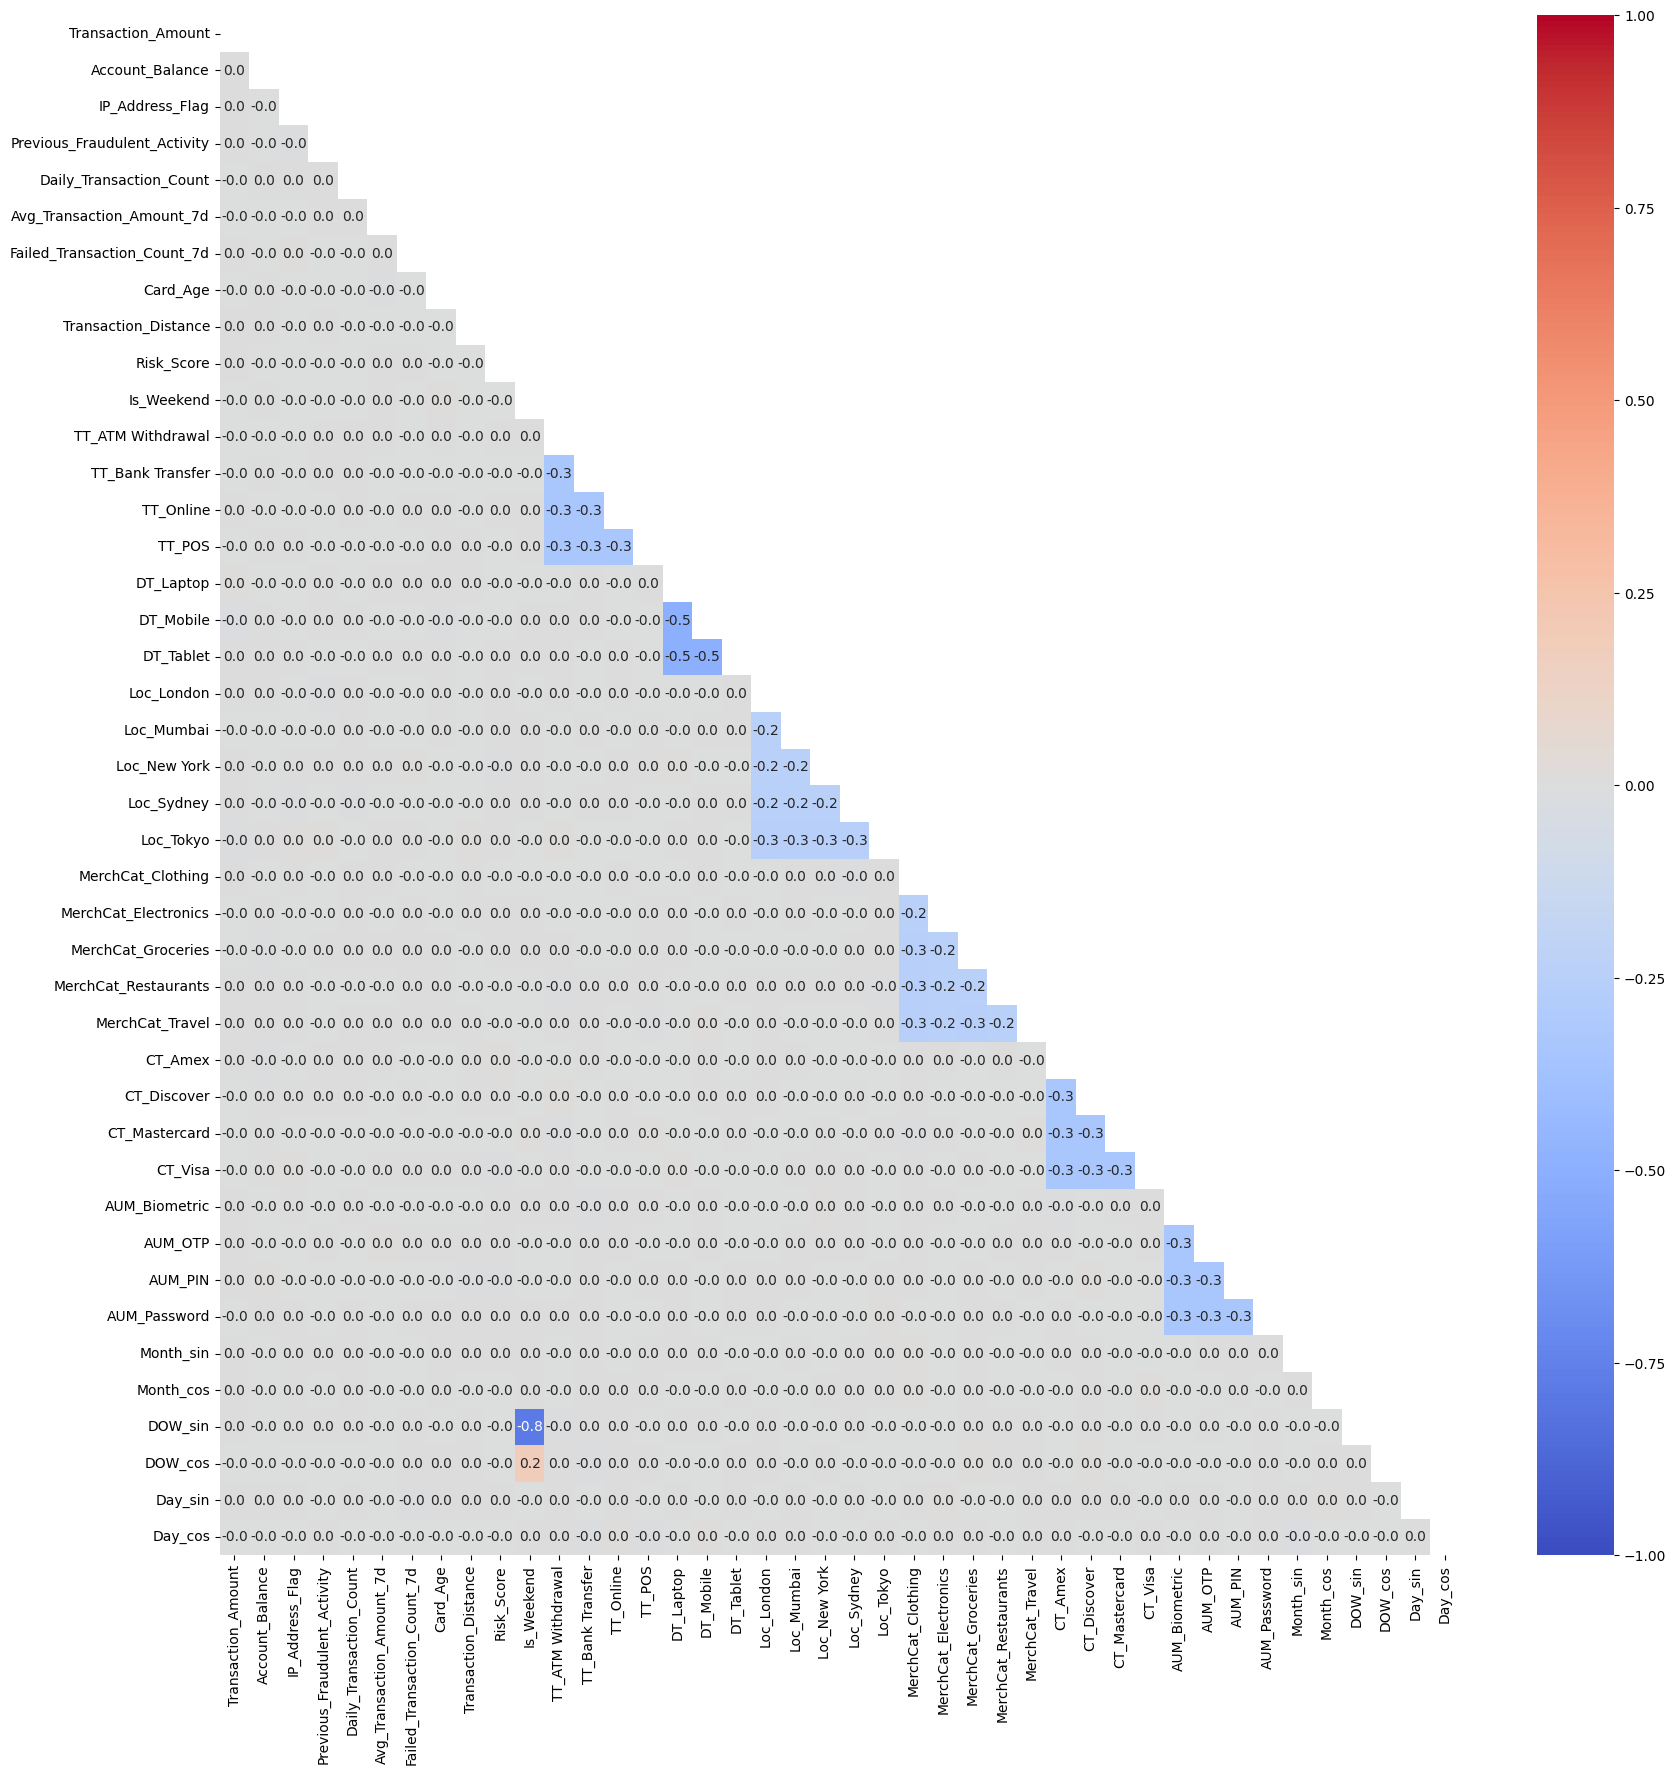

In [152]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

correlations = X.corr()

mask = np.triu(np.ones_like(correlations, dtype=bool))

plt.figure(figsize=(20,20))
sns.heatmap(
    correlations,
    mask=mask,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

In [153]:
df

,Transaction_ID,User_ID,Transaction_Amount,Timestamp,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,...,Month,Year,Day_of_Week,Quarter,Month_sin,Month_cos,DOW_sin,DOW_cos,Day_sin,Day_cos
0,TXN_33553,USER_1834,39.79,2023-08-14 19:30:00,93213.17,0.0,0.0,7.0,437.63,3.0,...,8,2023,0,3,-8.660254e-01,-5.000000e-01,0.000000,1.000000,0.299363,-0.954139
1,TXN_9427,USER_7875,1.19,2023-06-07 04:01:00,75725.25,0.0,0.0,13.0,478.76,4.0,...,6,2023,2,2,1.224647e-16,-1.000000e+00,0.974928,-0.222521,0.988468,0.151428
2,TXN_199,USER_2734,28.96,2023-06-20 15:25:00,1588.96,0.0,0.0,14.0,50.01,4.0,...,6,2023,1,2,1.224647e-16,-1.000000e+00,0.781831,0.623490,-0.790776,-0.612106
3,TXN_12447,USER_2617,254.32,2023-12-07 00:31:00,76807.20,0.0,0.0,8.0,182.48,4.0,...,12,2023,3,4,-2.449294e-16,1.000000e+00,0.433884,-0.900969,0.988468,0.151428
4,TXN_39489,USER_2014,31.28,2023-11-11 23:44:00,92354.66,0.0,1.0,14.0,328.69,4.0,...,11,2023,5,4,-5.000000e-01,8.660254e-01,-0.974928,-0.222521,0.790776,-0.612106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50007,TXN_11284,USER_4796,45.05,2023-01-29 18:38:00,76960.11,0.0,0.0,2.0,389.00,3.0,...,1,2023,6,1,5.000000e-01,8.660254e-01,-0.781831,0.623490,-0.394356,0.918958
50008,TXN_44732,USER_1171,126.15,2023-05-09 08:55:00,28791.75,0.0,0.0,13.0,434.95,4.0,...,5,2023,1,2,5.000000e-01,-8.660254e-01,0.781831,0.623490,0.968077,-0.250653
50009,TXN_38158,USER_2510,72.02,2023-01-30 19:32:00,29916.41,0.0,1.0,1.0,369.15,2.0,...,1,2023,0,1,5.000000e-01,8.660254e-01,0.000000,1.000000,-0.201299,0.979530
50010,TXN_860,USER_2248,64.89,2023-03-09 19:47:00,67895.67,0.0,0.0,13.0,242.29,4.0,...,3,2023,3,1,1.000000e+00,6.123234e-17,0.433884,-0.900969,0.968077,-0.250653


## 2.2. Dodavanje ekspertnih značajki
- iznos u odnosu na tipični
- indikactor transaction bursta
- vikend + online

In [158]:
from sklearn.preprocessing import StandardScaler

X["Amount_vs_Avg7d"] = df["Transaction_Amount"] / (df["Avg_Transaction_Amount_7d"] + 1)
# s obzirom da smo već ranije skalirali varijable, onda dodatno skaliramo ovu novu, ali inače bi bilo bolje (spretnije) napraviti skaliranje tek nakon što smo završili s dodavanjem/uklanjanjem varijabli
#new_scaler = StandardScaler()
#X["Amount_vs_Avg7d"] = new_scaler.fit_transform(X[["Amount_vs_Avg7d"]])

X["Txn_Burst"] = (df["Daily_Transaction_Count"] > 10).astype(int)
X["Weekend_Online"] = X["Is_Weekend"] * X["TT_Online"]

In [159]:
X

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,...,AUM_Password,Month_sin,Month_cos,DOW_sin,DOW_cos,Day_sin,Day_cos,Amount_vs_Avg7d,Txn_Burst,Weekend_Online
0,3.708437,1.492379,0.0,0.0,-0.120064,1.289857,0.704553,-0.797232,-1.120625,0.8494,...,False,-8.660254e-01,-5.000000e-01,0.000000,1.000000,0.299363,-0.954139,0.090714,0,False
1,0.783902,0.884311,0.0,0.0,1.365269,1.580771,1.411637,0.956808,-0.205103,0.0959,...,True,1.224647e-16,-1.000000e+00,0.974928,-0.222521,0.988468,0.151428,0.002480,1,False
2,3.399863,-1.693463,0.0,0.0,1.612825,-1.451796,1.411637,1.536656,-0.409034,0.8400,...,False,1.224647e-16,-1.000000e+00,0.781831,0.623490,-0.790776,-0.612106,0.567732,1,False
3,5.542518,0.921932,0.0,0.0,0.127491,-0.514830,1.411637,-0.637774,-0.823338,0.7935,...,False,-2.449294e-16,1.000000e+00,0.433884,-0.900969,0.988468,0.151428,1.386091,0,False
4,3.474448,1.462528,0.0,1.0,1.612825,0.519320,1.411637,0.289983,-1.062505,0.3819,...,True,-5.000000e-01,8.660254e-01,-0.974928,-0.222521,0.790776,-0.612106,0.094877,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50007,3.829728,0.927248,0.0,0.0,-1.357842,0.945895,0.704553,-0.318858,-0.666834,0.1493,...,False,5.000000e-01,8.660254e-01,-0.781831,0.623490,-0.394356,0.918958,0.115513,0,True
50008,4.845367,-0.747601,0.0,0.0,1.365269,1.270901,1.411637,-0.391339,0.039251,0.3653,...,False,5.000000e-01,-8.660254e-01,0.781831,0.623490,0.968077,-0.250653,0.289368,1,False
50009,4.290733,-0.708496,0.0,1.0,-1.605398,0.805495,-0.002531,-0.086919,1.516963,0.5195,...,False,5.000000e-01,8.660254e-01,0.000000,1.000000,-0.201299,0.979530,0.194570,0,False
50010,4.187987,0.612071,0.0,0.0,1.365269,-0.091791,1.411637,-0.695759,1.655887,0.7063,...,False,1.000000e+00,6.123234e-17,0.433884,-0.900969,0.968077,-0.250653,0.266719,1,False


## 2.2 PCA

Dimenzije X: (49998, 45)
Broj klasa u y: 2
Nazivi značajki:
['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score', 'Is_Weekend', 'TT_ATM Withdrawal', 'TT_Bank Transfer', 'TT_Online', 'TT_POS', 'DT_Laptop', 'DT_Mobile', 'DT_Tablet', 'Loc_London', 'Loc_Mumbai', 'Loc_New York', 'Loc_Sydney', 'Loc_Tokyo', 'MerchCat_Clothing', 'MerchCat_Electronics', 'MerchCat_Groceries', 'MerchCat_Restaurants', 'MerchCat_Travel', 'CT_Amex', 'CT_Discover', 'CT_Mastercard', 'CT_Visa', 'AUM_Biometric', 'AUM_OTP', 'AUM_PIN', 'AUM_Password', 'Month_sin', 'Month_cos', 'DOW_sin', 'DOW_cos', 'Day_sin', 'Day_cos', 'Amount_vs_Avg7d', 'Txn_Burst', 'Weekend_Online']

Matrica kovarijance:
[[ 1.00002     0.00466454  0.00247676 ...  0.36100611 -0.00623698
  -0.00274516]
 [ 0.00466454  1.00002    -0.00119897 ...  0.00328746  0.00625536
  -0.00297508]

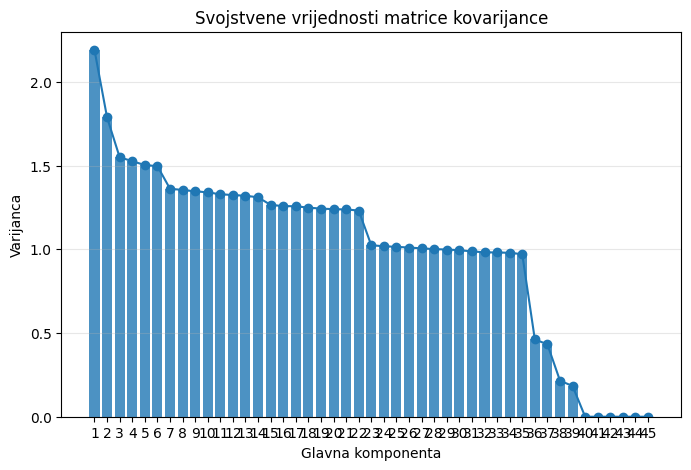

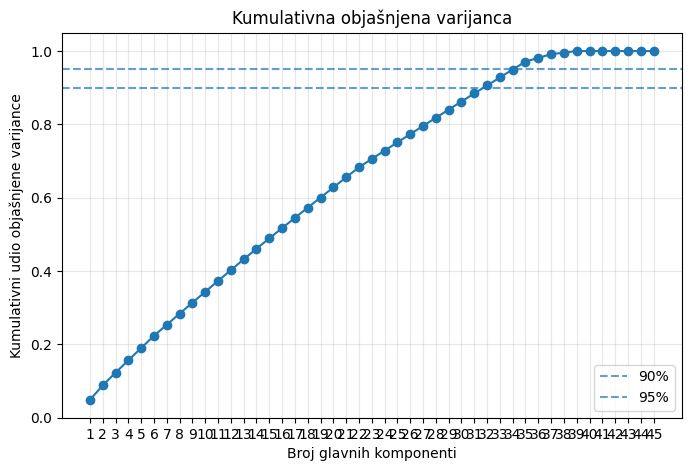


Broj komponenti za >= 90% varijance: 32
Broj komponenti za >= 95% varijance: 35


In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


np.random.seed(42)

print("Dimenzije X:", X.shape)
print("Broj klasa u y:", len(np.unique(y)))
print("Nazivi značajki:")
print(X.columns.tolist())



# -------------------------------------------------
# matrica kovarjance, eigenvalues, eigenvectors
# -------------------------------------------------
cov_matrix = np.cov(X_scaled.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nMatrica kovarijance:")
print(cov_matrix)

print("\nSvojstvene vrijednosti (eigenvalues):")
print(eigenvalues)

print("\nSvojstveni vektori (stupci su eigenvectors):")
print(eigenvectors)

print("\nVarijanca duž svake PC:")
print(pca_full.explained_variance_)

print("\nPCA komponente (redci su principal components):")
print(pca_full.components_)

print("\nNapomena: PCA komponente i eigenvektori mogu se razlikovati u predznaku,")
print("ali predstavljaju iste smjerove.")


plt.figure(figsize=(8, 5))

pcs = np.arange(1, len(eigenvalues) + 1)
plt.bar(pcs, eigenvalues, alpha=0.8, label="Eigenvalues")
plt.plot(pcs, eigenvalues, marker="o")

plt.xlabel("Glavna komponenta")
plt.ylabel("Varijanca")
plt.title("Svojstvene vrijednosti matrice kovarijance")
plt.xticks(pcs)
plt.grid(axis="y", alpha=0.3)
plt.show()


# Kumulativna objašnjena varijanca
plt.figure(figsize=(8, 5))

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
pcs = np.arange(1, len(cum_var) + 1)

plt.plot(pcs, cum_var, marker="o")
plt.axhline(0.90, linestyle="--", alpha=0.7, label="90%")
plt.axhline(0.95, linestyle="--", alpha=0.7, label="95%")

plt.xlabel("Broj glavnih komponenti")
plt.ylabel("Kumulativni udio objašnjene varijance")
plt.title("Kumulativna objašnjena varijanca")
plt.xticks(pcs)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -------------------------------------------------
# Koliko komponenti treba za 90% i 95% varijance
# -------------------------------------------------
n90 = np.argmax(cum_var >= 0.90) + 1
n95 = np.argmax(cum_var >= 0.95) + 1

print(f"\nBroj komponenti za >= 90% varijance: {n90}")
print(f"Broj komponenti za >= 95% varijance: {n95}")

Varijanca nije koncentrirana u par dimenzija, nego je razmazana preko mnogo značajki.
Dataset nije ni blizu niskodimenzionalne ravnine.

**PCA nije dobra metoda za agresivno smanjenje dimenzije u ovom slučaju.** To je bilo vidljivo i iz činjenice da nema pravih korelacija u prethodnoj analizi.